# 1D-CNN Pipeline on CIC-IDS2017
Standalone PyTorch pipeline with preprocessing, K-Fold CV, and final evaluation.

## Imports and config

In [1]:
import os
import glob
import math
import random
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import f1_score, classification_report, confusion_matrix
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt

DATASET_DIR = r"D:\Project\DL\1\cic-ids2017"
OUTPUT_DIR = r"D:\Project\DL\1"
RANDOM_STATE = 42
BATCH_SIZE = 1024
EPOCHS = 30
PATIENCE = 5
LR = 1e-3
NUM_FOLDS = 5

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


## Load and preprocess data

In [2]:
def load_cic_ids2017(dataset_dir):
    csv_files = glob.glob(os.path.join(dataset_dir, "*.csv"))
    if not csv_files:
        raise FileNotFoundError("No CSV files found in dataset directory.")
    df_list = []
    for f in csv_files:
        df_list.append(pd.read_csv(f, encoding='cp1252'))
    df = pd.concat(df_list, ignore_index=True)
    return df

def preprocess(df):
    df = df.copy()
    df.columns = df.columns.str.strip()
    if "Label" not in df.columns:
        raise ValueError("Expected 'Label' column not found.")

    df["Label"] = df["Label"].str.strip()

    # Normalize broken dashes and non-ASCII artifacts
    df["Label"] = df["Label"].str.replace("\x97", "-", regex=False)
    df["Label"] = df["Label"].str.replace("–", "-", regex=False)
    df["Label"] = df["Label"].str.replace("—", "-", regex=False)
    df["Label"] = df["Label"].str.replace("ï¿½", "-", regex=False)
    df["Label"] = df["Label"].str.replace(r"[^\x00-\x7F]", "", regex=True)
    df["Label"] = df["Label"].str.replace(r"\s+", " ", regex=True).str.strip()

    # Merge Web Attack variants
    df["Label"] = df["Label"].replace({
        "Web Attack - Brute Force": "Web Attack",
        "Web Attack - XSS": "Web Attack",
        "Web Attack - Sql Injection": "Web Attack"
    })

    df = df[~df["Label"].isin(["Heartbleed", "Infiltration"])]

    df = df.replace([np.inf, -np.inf], np.nan).dropna()

    feature_cols = [c for c in df.columns if c != "Label"]
    zero_var_cols = [c for c in feature_cols if df[c].nunique(dropna=False) <= 1]
    df = df.drop(columns=zero_var_cols)

    return df

df_raw = load_cic_ids2017(DATASET_DIR)
df = preprocess(df_raw)

X = df.drop(columns=["Label"])
y = df["Label"]

print("Rows:", len(df))
print("Features:", X.shape[1])
print("Classes:", y.nunique())
print("Unique labels:", sorted(y.unique().tolist()))

Rows: 2827829
Features: 70
Classes: 11
Unique labels: ['BENIGN', 'Bot', 'DDoS', 'DoS GoldenEye', 'DoS Hulk', 'DoS Slowhttptest', 'DoS slowloris', 'FTP-Patator', 'PortScan', 'SSH-Patator', 'Web Attack']


## Train/test split

In [3]:
le = LabelEncoder()
y_enc = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.2, random_state=RANDOM_STATE, stratify=y_enc
)

print("Train size:", X_train.shape, "Test size:", X_test.shape)
print("Classes:", le.classes_)

Train size: (2262263, 70) Test size: (565566, 70)
Classes: ['BENIGN' 'Bot' 'DDoS' 'DoS GoldenEye' 'DoS Hulk' 'DoS Slowhttptest'
 'DoS slowloris' 'FTP-Patator' 'PortScan' 'SSH-Patator' 'Web Attack']


## Model definition

In [4]:
class CNN1D(nn.Module):
    def __init__(self, num_features, num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.MaxPool1d(2),

            nn.Conv1d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.MaxPool1d(2),

            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.MaxPool1d(2),
        )

        with torch.no_grad():
            dummy = torch.zeros(1, num_features, 1)
            dummy = dummy.transpose(1, 2)
            out = self.net(dummy)
            flat_dim = out.view(1, -1).shape[1]

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(flat_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = x.transpose(1, 2)
        x = self.net(x)
        x = self.classifier(x)
        return x

def make_loaders(X_tr, y_tr, X_va, y_va, batch_size):
    X_tr_t = torch.tensor(X_tr, dtype=torch.float32).unsqueeze(2)
    y_tr_t = torch.tensor(y_tr, dtype=torch.long)
    X_va_t = torch.tensor(X_va, dtype=torch.float32).unsqueeze(2)
    y_va_t = torch.tensor(y_va, dtype=torch.long)

    train_ds = TensorDataset(X_tr_t, y_tr_t)
    val_ds = TensorDataset(X_va_t, y_va_t)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, pin_memory=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, pin_memory=True)
    return train_loader, val_loader

def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss = 0.0
    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * xb.size(0)
    return total_loss / len(loader.dataset)

def eval_one_epoch(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    all_preds = []
    all_true = []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)

            logits = model(xb)
            loss = criterion(logits, yb)
            total_loss += loss.item() * xb.size(0)

            preds = torch.argmax(logits, dim=1)
            all_preds.append(preds.cpu().numpy())
            all_true.append(yb.cpu().numpy())

    all_preds = np.concatenate(all_preds)
    all_true = np.concatenate(all_true)
    avg_loss = total_loss / len(loader.dataset)
    return avg_loss, all_true, all_preds

## K-Fold Cross Validation

In [5]:
skf = StratifiedKFold(n_splits=NUM_FOLDS, shuffle=True, random_state=RANDOM_STATE)

fold_results = []
best_fold = None
best_val_loss = math.inf
best_state_dict = None
best_scaler = None

X_train_np = X_train.values
y_train_np = np.array(y_train)

for fold, (tr_idx, va_idx) in enumerate(skf.split(X_train_np, y_train_np), start=1):
    X_tr, X_va = X_train_np[tr_idx], X_train_np[va_idx]
    y_tr, y_va = y_train_np[tr_idx], y_train_np[va_idx]

    scaler = StandardScaler()
    X_tr = scaler.fit_transform(X_tr)
    X_va = scaler.transform(X_va)

    class_counts = np.bincount(y_tr, minlength=len(le.classes_))
    safe_counts = np.maximum(class_counts, 1)
    class_weights = class_counts.sum() / (len(class_counts) * safe_counts)
    class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)

    model = CNN1D(num_features=X_tr.shape[1], num_classes=len(le.classes_)).to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)

    train_loader, val_loader = make_loaders(X_tr, y_tr, X_va, y_va, BATCH_SIZE)

    best_epoch_loss = math.inf
    epochs_no_improve = 0

    for epoch in range(1, EPOCHS + 1):
        tr_loss = train_one_epoch(model, train_loader, criterion, optimizer)
        va_loss, va_true, va_pred = eval_one_epoch(model, val_loader, criterion)

        if va_loss < best_epoch_loss:
            best_epoch_loss = va_loss
            epochs_no_improve = 0
            best_epoch_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        else:
            epochs_no_improve += 1

        if epochs_no_improve >= PATIENCE:
            break

    model.load_state_dict(best_epoch_state)
    va_loss, va_true, va_pred = eval_one_epoch(model, val_loader, criterion)
    macro_f1 = f1_score(va_true, va_pred, average="macro")
    report = classification_report(va_true, va_pred, target_names=le.classes_, digits=4)

    fold_results.append({
        "fold": fold,
        "val_loss": va_loss,
        "macro_f1": macro_f1,
        "report": report
    })

    if va_loss < best_val_loss:
        best_val_loss = va_loss
        best_fold = fold
        best_state_dict = best_epoch_state
        best_scaler = scaler

    print(f"Fold {fold} | val_loss={va_loss:.4f} | macro_f1={macro_f1:.4f}")

print("Best fold:", best_fold, "Best val loss:", best_val_loss)

Fold 1 | val_loss=0.0692 | macro_f1=0.6517
Fold 2 | val_loss=0.0779 | macro_f1=0.6409
Fold 3 | val_loss=0.0782 | macro_f1=0.6728
Fold 4 | val_loss=0.0746 | macro_f1=0.6220
Fold 5 | val_loss=0.0680 | macro_f1=0.6303
Best fold: 5 Best val loss: 0.06798111546265959


## Per-fold evaluation reports

In [6]:
for fr in fold_results:
    print("\nFold", fr["fold"], "macro_f1", f"{fr['macro_f1']:.4f}")
    print(fr["report"])


Fold 1 macro_f1 0.6517
                  precision    recall  f1-score   support

          BENIGN     0.9999    0.8985    0.9465    363412
             Bot     0.0316    0.9936    0.0612       313
            DDoS     0.7616    0.9992    0.8643     20484
   DoS GoldenEye     0.5546    0.9988    0.7132      1647
        DoS Hulk     0.8505    0.9982    0.9185     36819
DoS Slowhttptest     0.6412    0.9909    0.7786       880
   DoS slowloris     0.5453    0.9860    0.7023       927
     FTP-Patator     0.4802    0.9906    0.6468      1270
        PortScan     0.8239    0.9989    0.9030     25409
     SSH-Patator     0.3026    0.9894    0.4635       943
      Web Attack     0.0939    0.9284    0.1705       349

        accuracy                         0.9181    452453
       macro avg     0.5532    0.9793    0.6517    452453
    weighted avg     0.9595    0.9181    0.9333    452453


Fold 2 macro_f1 0.6409
                  precision    recall  f1-score   support

          BENIGN    

## Final evaluation on held-out test set

Test macro F1: 0.6319932797204912
                  precision    recall  f1-score   support

          BENIGN     0.9999    0.8941    0.9441    454264
             Bot     0.0330    1.0000    0.0638       391
            DDoS     0.7739    0.9987    0.8721     25605
   DoS GoldenEye     0.5374    0.9976    0.6985      2059
        DoS Hulk     0.8413    0.9988    0.9134     46025
DoS Slowhttptest     0.5569    0.9882    0.7123      1100
   DoS slowloris     0.5017    0.9931    0.6667      1159
     FTP-Patator     0.5110    0.9956    0.6754      1587
        PortScan     0.8217    0.9986    0.9016     31761
     SSH-Patator     0.1959    0.9890    0.3270      1179
      Web Attack     0.0980    0.9266    0.1772       436

        accuracy                         0.9146    565566
       macro avg     0.5337    0.9800    0.6320    565566
    weighted avg     0.9588    0.9146    0.9308    565566

Saved confusion matrix to D:\Project\DL\1\confusion_matrix.png


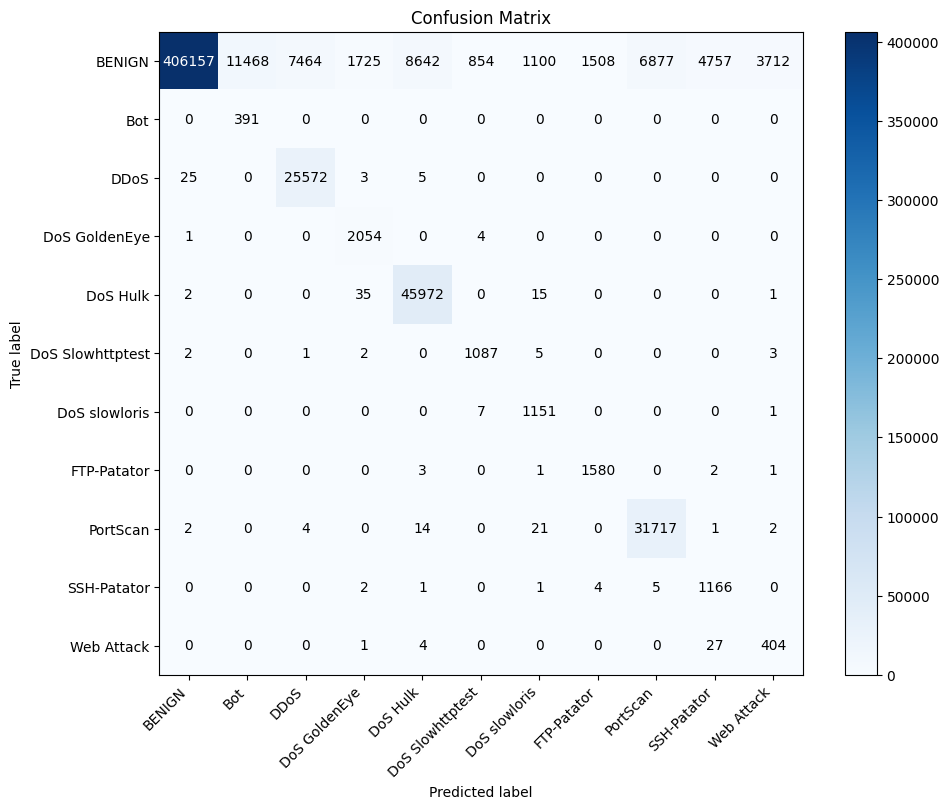

In [9]:
# Use scaler from the best fold (no mismatch)
scaler_mean = torch.tensor(best_scaler.mean_, dtype=torch.float32).to(device)
scaler_scale = torch.tensor(best_scaler.scale_, dtype=torch.float32).to(device)

# Rebuild model and load best fold weights
model = CNN1D(num_features=X_train.shape[1], num_classes=len(le.classes_)).to(device)
model.load_state_dict(best_state_dict)
model.eval()

X_test_t = torch.tensor(X_test.values, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.long)

test_loader = DataLoader(
    TensorDataset(X_test_t, y_test_t),
    batch_size=BATCH_SIZE,
    shuffle=False,
    pin_memory=True
)

all_preds = []
with torch.no_grad():
    for xb, _ in test_loader:
        xb = xb.to(device)
        xb = (xb - scaler_mean) / scaler_scale
        xb = xb.unsqueeze(2)
        logits = model(xb)
        preds = torch.argmax(logits, dim=1)
        all_preds.append(preds.cpu().numpy())

y_pred = np.concatenate(all_preds)
macro_f1 = f1_score(y_test, y_pred, average="macro")
print("Test macro F1:", macro_f1)

report = classification_report(y_test, y_pred, target_names=le.classes_, digits=4)
print(report)

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
plt.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.colorbar()
tick_marks = np.arange(len(le.classes_))
plt.xticks(tick_marks, le.classes_, rotation=45, ha="right")
plt.yticks(tick_marks, le.classes_)

thresh = cm.max() / 2.0
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j, i, f"{cm[i, j]}",
            ha="center", va="center",
            color="white" if cm[i, j] > thresh else "black"
        )

plt.tight_layout()
plt.ylabel("True label")
plt.xlabel("Predicted label")

cm_path = os.path.join(OUTPUT_DIR, "confusion_matrix.png")
plt.savefig(cm_path, dpi=200)
print("Saved confusion matrix to", cm_path)